In [ ]:
! pip install tensorflow

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense ,Dropout,BatchNormalization

Data Downloading

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
! kaggle datasets download -d ashery/chexpert

Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [08:40<00:00, 22.1MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('/content/chexpert.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done")

Done


Data Preprocessing

In [ ]:
df_train=pd.read_csv('/content/dataset/train.csv')
df_valid=pd.read_csv('/content/dataset/valid.csv')

In [ ]:
df_train.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [ ]:
df_train=df_train.loc[df_train.isnull().sum(axis=1).nsmallest(5000).index]


In [ ]:
df_train

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
15265,CheXpert-v1.0-small/train/patient03803/study7/...,Male,76,Frontal,PA,NaN,-1.0,-1.0,1.0,NaN,0.0,0.0,NaN,-1.0,0.0,-1.0,-1.0,NaN,0.0
19452,CheXpert-v1.0-small/train/patient04837/study1/...,Male,87,Frontal,PA,NaN,-1.0,1.0,-1.0,NaN,0.0,0.0,NaN,-1.0,0.0,1.0,-1.0,1.0,NaN
37959,CheXpert-v1.0-small/train/patient09313/study1/...,Male,60,Frontal,AP,NaN,0.0,NaN,1.0,1.0,1.0,1.0,-1.0,-1.0,0.0,1.0,NaN,NaN,1.0
80312,CheXpert-v1.0-small/train/patient19317/study36...,Male,42,Frontal,PA,NaN,-1.0,NaN,1.0,NaN,0.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,NaN,1.0
116061,CheXpert-v1.0-small/train/patient27819/study1/...,Female,64,Frontal,PA,NaN,0.0,0.0,1.0,0.0,0.0,0.0,NaN,1.0,0.0,-1.0,-1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192524,CheXpert-v1.0-small/train/patient46495/study1/...,Female,72,Frontal,AP,NaN,NaN,NaN,1.0,NaN,1.0,-1.0,NaN,-1.0,0.0,1.0,NaN,NaN,1.0
192565,CheXpert-v1.0-small/train/patient46514/study4/...,Male,90,Frontal,AP,NaN,-1.0,NaN,NaN,NaN,1.0,-1.0,NaN,-1.0,0.0,1.0,NaN,NaN,1.0
192588,CheXpert-v1.0-small/train/patient46521/study2/...,Female,71,Frontal,AP,NaN,-1.0,NaN,0.0,NaN,1.0,NaN,NaN,1.0,0.0,1.0,NaN,NaN,1.0
192616,CheXpert-v1.0-small/train/patient46529/study6/...,Female,86,Frontal,AP,NaN,1.0,NaN,1.0,NaN,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,1.0,1.0


In [ ]:
df_train.isnull().sum()

,0
Path,0
Sex,0
Age,0
Frontal/Lateral,0
AP/PA,222
No Finding,4685
Enlarged Cardiomediastinum,2594
Cardiomegaly,2508
Lung Opacity,701
Lung Lesion,4246


In [ ]:
df_train=df_train.drop(['Sex', 'Age', 'Frontal/Lateral', 'AP/PA','No Finding','Lung Lesion','Pleural Other','Fracture' ], axis=1)
df_valid=df_valid.drop(['Sex', 'Age', 'Frontal/Lateral', 'AP/PA','No Finding','Lung Lesion','Pleural Other','Fracture' ], axis=1)

In [ ]:
df_train

,Path,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Support Devices
15265,CheXpert-v1.0-small/train/patient03803/study7/...,-1.0,-1.0,1.0,0.0,0.0,NaN,-1.0,0.0,-1.0,0.0
19452,CheXpert-v1.0-small/train/patient04837/study1/...,-1.0,1.0,-1.0,0.0,0.0,NaN,-1.0,0.0,1.0,NaN
37959,CheXpert-v1.0-small/train/patient09313/study1/...,0.0,NaN,1.0,1.0,1.0,-1.0,-1.0,0.0,1.0,1.0
80312,CheXpert-v1.0-small/train/patient19317/study36...,-1.0,NaN,1.0,0.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0
116061,CheXpert-v1.0-small/train/patient27819/study1/...,0.0,0.0,1.0,0.0,0.0,NaN,1.0,0.0,-1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
192524,CheXpert-v1.0-small/train/patient46495/study1/...,NaN,NaN,1.0,1.0,-1.0,NaN,-1.0,0.0,1.0,1.0
192565,CheXpert-v1.0-small/train/patient46514/study4/...,-1.0,NaN,NaN,1.0,-1.0,NaN,-1.0,0.0,1.0,1.0
192588,CheXpert-v1.0-small/train/patient46521/study2/...,-1.0,NaN,0.0,1.0,NaN,NaN,1.0,0.0,1.0,1.0
192616,CheXpert-v1.0-small/train/patient46529/study6/...,1.0,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,1.0


In [ ]:
df_valid.isnull().sum()

,0
Path,0
Enlarged Cardiomediastinum,0
Cardiomegaly,0
Lung Opacity,0
Edema,0
Consolidation,0
Pneumonia,0
Atelectasis,0
Pneumothorax,0
Pleural Effusion,0


In [ ]:
df_train=df_train.fillna(0)
df_train=df_train.replace(-1,0)
df_valid=df_valid.replace(-1,0)

In [ ]:
df_train

,Path,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Support Devices
15265,CheXpert-v1.0-small/train/patient03803/study7/...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19452,CheXpert-v1.0-small/train/patient04837/study1/...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
37959,CheXpert-v1.0-small/train/patient09313/study1/...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
80312,CheXpert-v1.0-small/train/patient19317/study36...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
116061,CheXpert-v1.0-small/train/patient27819/study1/...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
192524,CheXpert-v1.0-small/train/patient46495/study1/...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
192565,CheXpert-v1.0-small/train/patient46514/study4/...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
192588,CheXpert-v1.0-small/train/patient46521/study2/...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
192616,CheXpert-v1.0-small/train/patient46529/study6/...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
df_train.isnull().sum()

,0
Path,0
Enlarged Cardiomediastinum,0
Cardiomegaly,0
Lung Opacity,0
Edema,0
Consolidation,0
Pneumonia,0
Atelectasis,0
Pneumothorax,0
Pleural Effusion,0


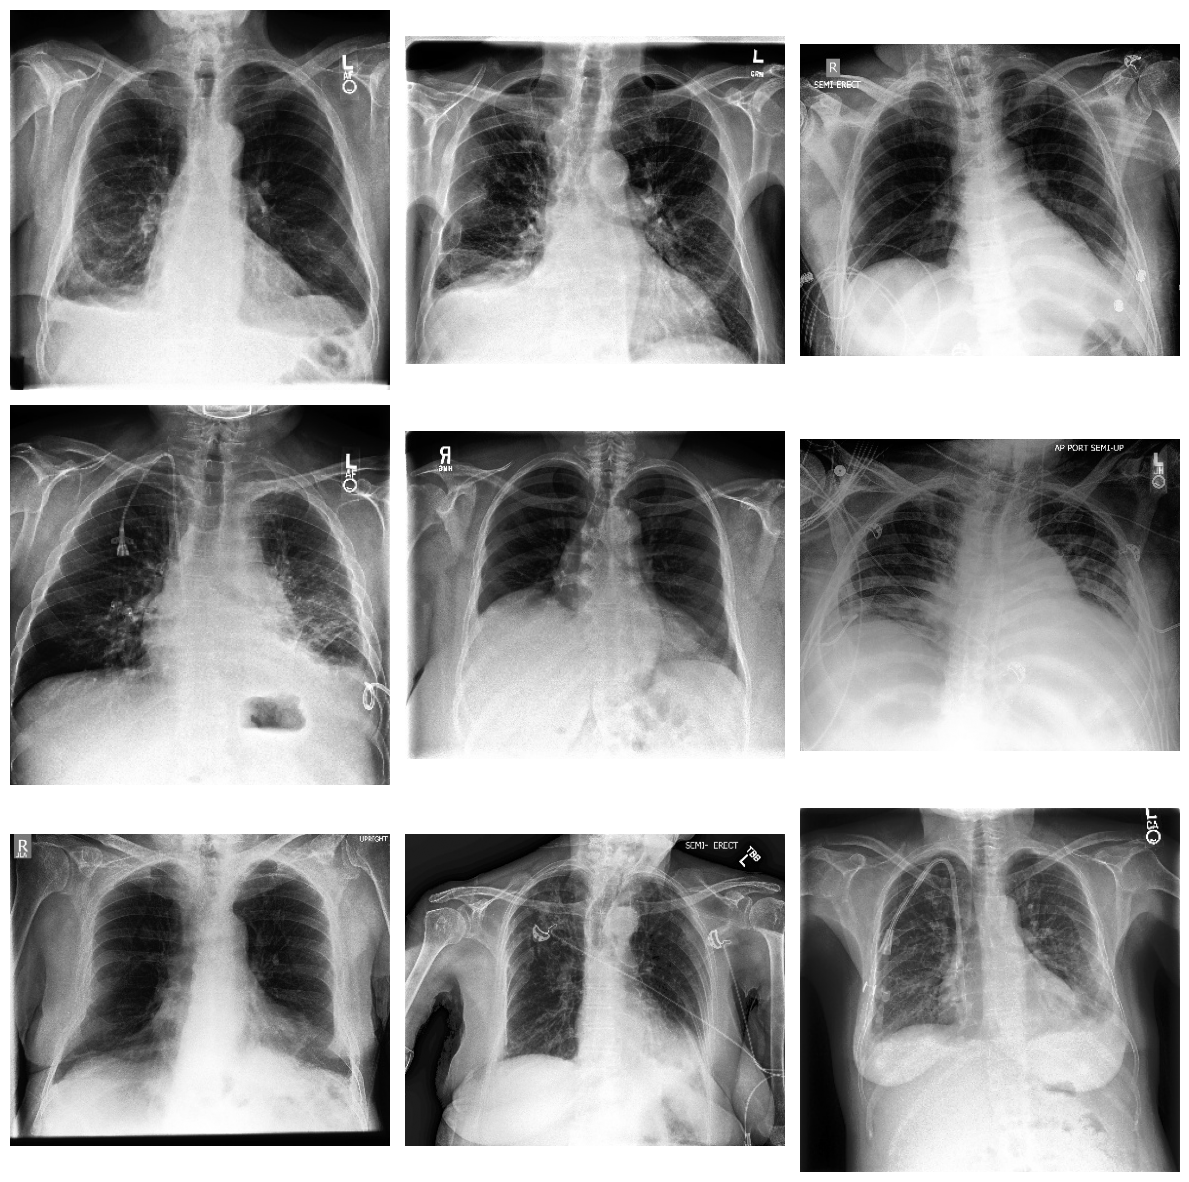

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Apply path corrections to df_train["Path"] to ensure correct file locations.
# This handles the case where the dataset extracts directly into /content/dataset/
# without the 'CheXpert-v1.0-small' subdirectory.
# It also ensures the correct /content/dataset/ prefix is present.

# Step 1: Remove 'CheXpert-v1.0-small/' from the path if it exists.
# This handles initial paths from CSV and paths that might have been
# prefixed with '/content/dataset/CheXpert-v1.0-small/' previously.
df_train["Path"] = df_train["Path"].str.replace("CheXpert-v1.0-small/", "", regex=False)

# Step 2: Ensure the path starts with '/content/dataset/'
# This step ensures the correct root directory,
# handling cases where it's missing or if previous replacements
# altered the start of the path.
if not df_train["Path"].iloc[0].startswith("/content/dataset/"):
    df_train["Path"] = "/content/dataset/" + df_train["Path"]

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    # Corrected 'train_df' to 'df_train'
    img = Image.open(df_train["Path"].iloc[i])

    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
df_valid["Path"] = df_valid["Path"].str.replace("CheXpert-v1.0-small/", "", regex=False)
if not df_valid["Path"].iloc[0].startswith("/content/dataset/"):
    df_valid["Path"] = "/content/dataset/" + df_valid["Path"]


In [ ]:
df_valid , df_test =train_test_split(df_valid , test_size=0.5 , shuffle=True, random_state=42)


In [ ]:
df_train.shape , df_valid.shape , df_test.shape

((5000, 11), (117, 11), (117, 11))

In [ ]:
labels=df_train.columns[1:]
labels

Index(['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Edema',
       'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax',
       'Pleural Effusion', 'Support Devices'],
      dtype='object')

Pretrained Model

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

#Feature Extraction
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

In [ ]:
#Data Augmentation
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=5,
    fill_mode='nearest'
)
ts_gen=ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
batch_size=16
img_size=(224,224)

train_gen=tr_gen.flow_from_dataframe(
    df_train,
    x_col='Path',
    y_col=labels,
    target_size=img_size,
    class_mode='raw',
    batch_size=batch_size,
    shuffle=True)


valid_gen=ts_gen.flow_from_dataframe(
    df_valid,
    x_col='Path',
    y_col=labels,
    target_size=img_size,
    class_mode='raw',
    batch_size=batch_size,
    shuffle=True)

test_gen=ts_gen.flow_from_dataframe(
    df_test,
    x_col='Path',
    y_col=labels,
    target_size=img_size,
    class_mode='raw',
    batch_size=batch_size,
    shuffle=False)

Found 5000 validated image filenames.
Found 117 validated image filenames.
Found 117 validated image filenames.


In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Sequential

model=Sequential([
    base_model,
    GlobalAveragePooling2D(), # Add this layer to flatten the feature maps
    BatchNormalization(),
    Dense(128,kernel_regularizer=regularizers.l2(1e-3), activation='relu'),
    Dropout(0.5),
    Dense(10, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,174,090 (27.37 MB)

 Trainable params: 134,538 (525.54 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
call_backs = [ EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
),
     ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.2,
    min_lr=1e-6,
    verbose=1
),
     ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1


),
]

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)

In [ ]:
history=model.fit(train_gen,epochs=50,validation_data=valid_gen,callbacks=call_backs)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6968 - auc: 0.5650 - loss: 0.7728
Epoch 1: val_loss improved from None to 0.63555, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 400ms/step - accuracy: 0.7541 - auc: 0.5881 - loss: 0.6798 - val_accuracy: 0.7444 - val_auc: 0.6841 - val_loss: 0.6356 - learning_rate: 5.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7987 - auc: 0.6386 - loss: 0.5757
Epoch 2: val_loss improved from 0.63555 to 0.62433, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 254ms/step - accuracy: 0.7997 - auc: 0.6429 - loss: 0.5657 - val_accuracy: 0.7402 - val_auc: 0.7290 - val_loss: 0.6243 - learning_rate: 5.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8053 - auc: 0.6656 - loss: 0.5370
Epoch 3: val_loss improved from 0.62433 to 0.60331, saving mod

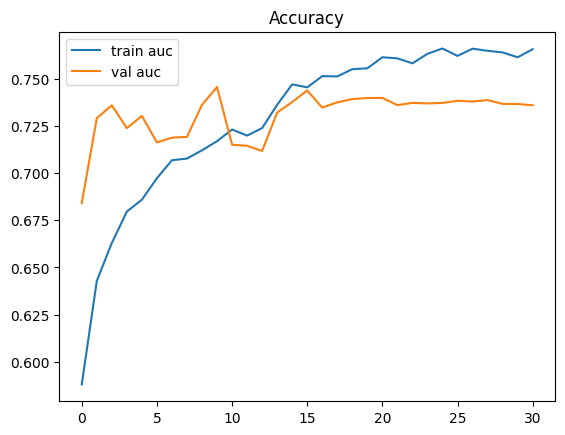

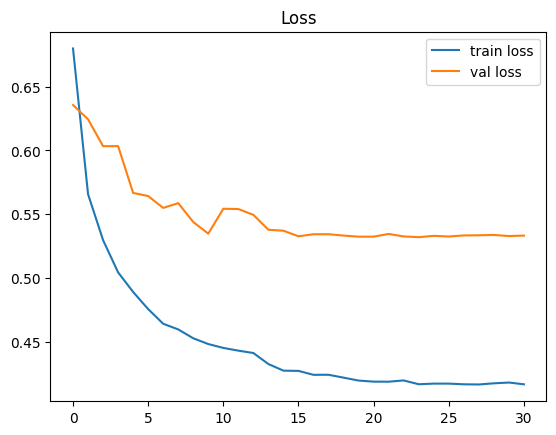

In [ ]:
plt.plot(history.history['auc'], label='train auc')
plt.plot(history.history['val_auc'], label='val auc')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

Fine Tunning

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping


print("Loading the best model...")
model = load_model('best_model.keras')


base_model = model.layers[0]
base_model.trainable = True

# Openning last 30 layers
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)

model.summary()


Loading the best model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,174,090 (27.37 MB)

 Trainable params: 775,946 (2.96 MB)

 Non-trainable params: 6,398,144 (24.41 MB)

In [ ]:
ft_call_backs = [
    ModelCheckpoint(
        filepath='best_model_finetuned.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]


print("Starting Fine-Tuning...")
history_fine = model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    callbacks=ft_call_backs
)

Starting Fine-Tuning...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8295 - auc: 0.7560 - loss: 0.4188
Epoch 1: val_loss improved from None to 0.54250, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 389ms/step - accuracy: 0.8274 - auc: 0.7582 - loss: 0.4208 - val_accuracy: 0.7496 - val_auc: 0.7295 - val_loss: 0.5425 - learning_rate: 1.0000e-05
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8282 - auc: 0.7596 - loss: 0.4175
Epoch 2: val_loss improved from 0.54250 to 0.54129, saving model to best_model_finetuned.keras

Epoch 2: finished saving model to best_model_finetuned.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.8266 - auc: 0.7619 - loss: 0.4192 - val_accuracy: 0.7521 - val_auc: 0.7264 - val_loss: 0.5413 - learning_rate: 1.0000e-05
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8270 - auc: 0.7586 - loss: 0.420

Model Testing

In [ ]:

from tensorflow.keras.models import load_model
print("Loading the final finetuned model...")
final_model = load_model('best_model_finetuned.keras')


print("Evaluating on Test Set...")
test_results = final_model.evaluate(test_gen, verbose=1)


for name, value in zip(final_model.metrics_names, test_results):
    print(f"Test {name}: {value:.4f}")

Loading the final finetuned model...
Evaluating on Test Set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7376 - auc: 0.7293 - loss: 0.5649
Test loss: 0.5649
Test compile_metrics: 0.7376
